# SliderEdit Evaluation Results Visualization

This notebook visualizes the evaluation metrics calculated by `evaluation.py` for SliderEdit image editing.

**Scale Convention in SliderEdit**:
- `1.0`: Preserved base image (Unedited / Original state)
- `0.0`: Full edit applied
- `-1.0`: Strong / Exaggerated edit applied

The x-axes are plotted from `1.0 -> 0.0 -> -1.0` to show the progression from the unedited reference image to maximum edit strength.

In [6]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
})

# Relative path to evaluation_results.csv from experiments directory
csv_path = os.path.abspath("../../outputs/slideredit/stlora/evaluation_results.csv")
if not os.path.exists(csv_path):
    csv_path = "../evaluation_results.csv"

df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} records across {df['domain'].nunique()} domains:")
print(df['domain'].value_counts())

Loaded 82 records across 5 domains:
domain
Scene / Light     27
Fashion           18
Portraits         18
Typography        10
Product Design     9
Name: count, dtype: int64


## 1. VLM Alignment Scores vs. Slider 1 Scale (Preserved 1.0 -> Full 0.0 -> Strong -1.0)

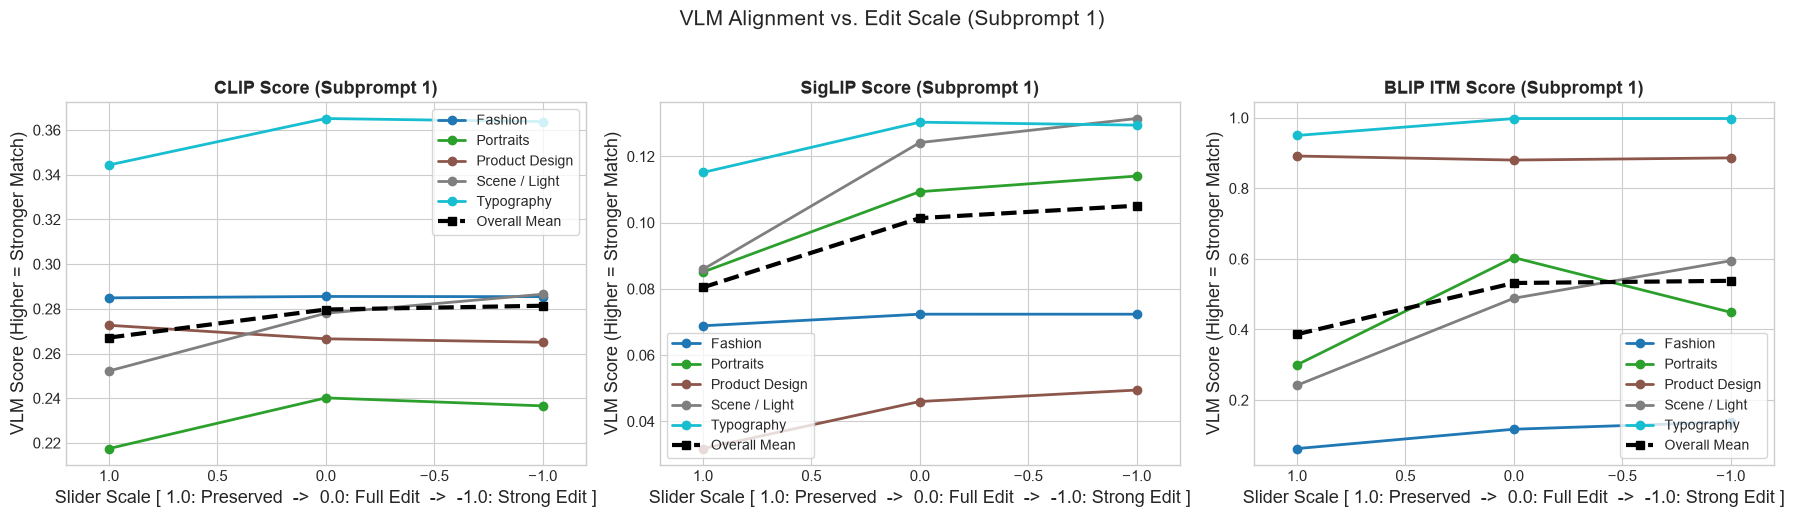

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_vlm = [
    ("VLM_CLIP_subprompt1", "CLIP Score (Subprompt 1)"),
    ("VLM_Siglip_subprompt1", "SigLIP Score (Subprompt 1)"),
    ("VLM_BLIP_subprompt1", "BLIP ITM Score (Subprompt 1)"),
]

domains = df['domain'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(domains)))

for i, (col_name, title) in enumerate(metrics_vlm):
    ax = axes[i]
    if col_name in df.columns:
        grouped = df.groupby(['domain', 'slider1_val'])[col_name].mean().reset_index()
        for j, dom in enumerate(domains):
            dom_data = grouped[grouped['domain'] == dom].sort_values(by='slider1_val', ascending=False)
            ax.plot(dom_data['slider1_val'], dom_data[col_name], marker='o', linewidth=2, label=dom, color=colors[j])
        
        overall = df.groupby('slider1_val')[col_name].mean().reset_index().sort_values(by='slider1_val', ascending=False)
        ax.plot(overall['slider1_val'], overall[col_name], marker='s', linewidth=3, linestyle='--', label='Overall Mean', color='black')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Slider Scale [ 1.0: Preserved  ->  0.0: Full Edit  ->  -1.0: Strong Edit ]")
    ax.set_ylabel("VLM Score (Higher = Stronger Match)")
    ax.set_xlim(1.2, -1.2)
    ax.legend(frameon=True)

fig.suptitle("VLM Alignment vs. Edit Scale (Subprompt 1)", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

## 2. VLM Alignment Scores vs. Slider 2 Scale

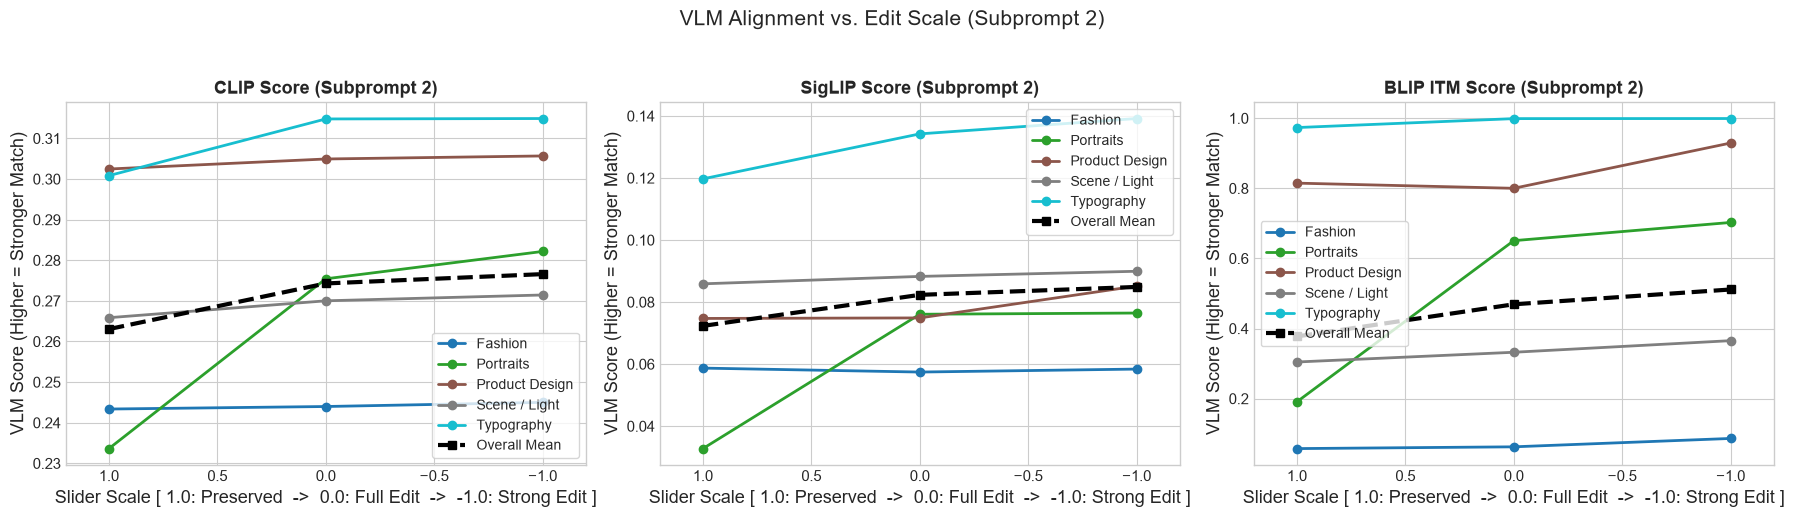

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_vlm2 = [
    ("VLM_CLIP_subprompt2", "CLIP Score (Subprompt 2)"),
    ("VLM_Siglip_subprompt2", "SigLIP Score (Subprompt 2)"),
    ("VLM_BLIP_subprompt2", "BLIP ITM Score (Subprompt 2)"),
]

for i, (col_name, title) in enumerate(metrics_vlm2):
    ax = axes[i]
    if col_name in df.columns:
        grouped = df.groupby(['domain', 'slider2_val'])[col_name].mean().reset_index()
        for j, dom in enumerate(domains):
            dom_data = grouped[grouped['domain'] == dom].sort_values(by='slider2_val', ascending=False)
            ax.plot(dom_data['slider2_val'], dom_data[col_name], marker='o', linewidth=2, label=dom, color=colors[j])
        
        overall = df.groupby('slider2_val')[col_name].mean().reset_index().sort_values(by='slider2_val', ascending=False)
        ax.plot(overall['slider2_val'], overall[col_name], marker='s', linewidth=3, linestyle='--', label='Overall Mean', color='black')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Slider Scale [ 1.0: Preserved  ->  0.0: Full Edit  ->  -1.0: Strong Edit ]")
    ax.set_ylabel("VLM Score (Higher = Stronger Match)")
    ax.set_xlim(1.2, -1.2)
    ax.legend(frameon=True)

fig.suptitle("VLM Alignment vs. Edit Scale (Subprompt 2)", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

## 3. Distance from Preserved Image vs. Edit Scale

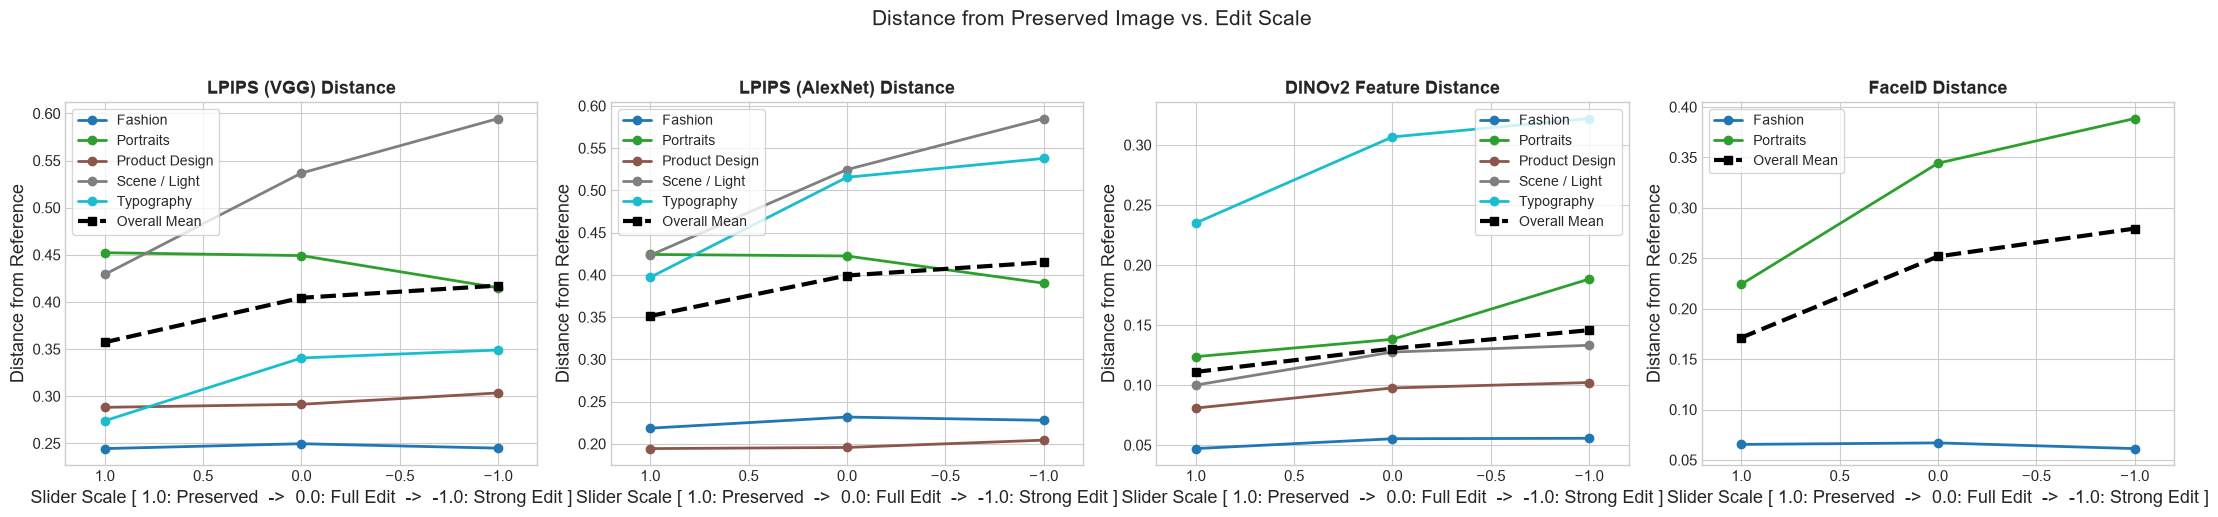

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
metrics_dist = [
    ("Dist_LPIPS_vgg", "LPIPS (VGG) Distance"),
    ("Dist_LPIPS_alex", "LPIPS (AlexNet) Distance"),
    ("Dist_DiNOv2", "DINOv2 Feature Distance"),
    ("Dist_FaceID", "FaceID Distance"),
]

for i, (col_name, title) in enumerate(metrics_dist):
    ax = axes[i]
    if col_name in df.columns and not df[col_name].isna().all():
        grouped = df.groupby(['domain', 'slider1_val'])[col_name].mean().reset_index()
        for j, dom in enumerate(domains):
            dom_data = grouped[grouped['domain'] == dom].sort_values(by='slider1_val', ascending=False)
            if not dom_data[col_name].isna().all():
                ax.plot(dom_data['slider1_val'], dom_data[col_name], marker='o', linewidth=2, label=dom, color=colors[j])
        
        overall = df.groupby('slider1_val')[col_name].mean().reset_index().sort_values(by='slider1_val', ascending=False)
        ax.plot(overall['slider1_val'], overall[col_name], marker='s', linewidth=3, linestyle='--', label='Overall Mean', color='black')

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Slider Scale [ 1.0: Preserved  ->  0.0: Full Edit  ->  -1.0: Strong Edit ]")
    ax.set_ylabel("Distance from Reference")
    ax.set_xlim(1.2, -1.2)
    ax.legend(frameon=True)

fig.suptitle("Distance from Preserved Image vs. Edit Scale", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()

## 4. Domain Bar Comparison

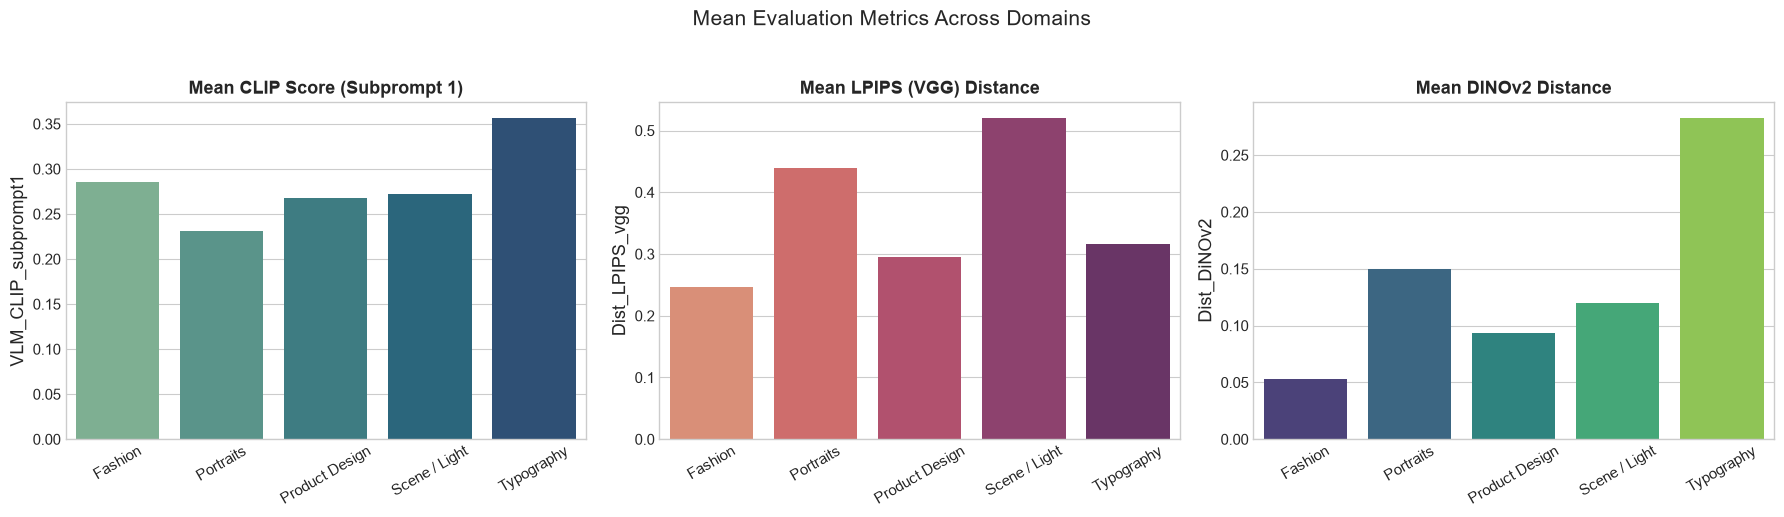

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
domain_means = df.groupby('domain')[['VLM_CLIP_subprompt1', 'Dist_LPIPS_vgg', 'Dist_DiNOv2']].mean().reset_index()

sns.barplot(data=domain_means, x='domain', y='VLM_CLIP_subprompt1', hue='domain', ax=axes[0], palette='crest', legend=False)
axes[0].set_title("Mean CLIP Score (Subprompt 1)", fontweight='bold')
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=domain_means, x='domain', y='Dist_LPIPS_vgg', hue='domain', ax=axes[1], palette='flare', legend=False)
axes[1].set_title("Mean LPIPS (VGG) Distance", fontweight='bold')
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=30)

sns.barplot(data=domain_means, x='domain', y='Dist_DiNOv2', hue='domain', ax=axes[2], palette='viridis', legend=False)
axes[2].set_title("Mean DINOv2 Distance", fontweight='bold')
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=30)

fig.suptitle("Mean Evaluation Metrics Across Domains", fontsize=15, y=1.03)
fig.tight_layout()
plt.show()